Lets create a NERF from scatch!

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Dataset, TensorDataset
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(device)

mps


In [2]:
data = np.load(f"lego_200x200.npz")

# Training images: [100, 200, 200, 3]
images_train = data["images_train"] / 255.0

# Cameras for the training images
# (camera-to-world transformation matrix): [100, 4, 4]
c2ws_train = data["c2ws_train"]

# Validation images:
images_val = data["images_val"] / 255.0

# Cameras for the validation images: [10, 4, 4]
# (camera-to-world transformation matrix): [10, 200, 200, 3]
c2ws_val = data["c2ws_val"]

# Test cameras for novel-view video rendering:
# (camera-to-world transformation matrix): [60, 4, 4]
c2ws_test = data["c2ws_test"]

# Camera focal length
focal = data["focal"]  # float

focal = float(focal)
K = torch.tensor([[focal, 0, 100,], [0, focal, 100,], [0, 0, 1]], dtype=torch.float32).to(device)


In [3]:
# Here we are transforming 3D camera coordinates to 3D world coordinates
x = torch.tensor([5.5, 0.5, 0.5]).to(device)
print(x)
x = x.repeat(9, 1).T.float()
# print(x.shape)
c2w = torch.tensor(c2ws_train[0]).float()
print(c2w)
def transform_c2w(c2w, x):
    """
    input:
    c2w [4,4]
    x [3, B]

    output:
    [3, B]
    """
    x = x.to(device)
    c2w = c2w.to(device)
    ones = torch.ones(1, x.shape[1], device=device)
    x = torch.cat((x, ones), dim=0)
    out = c2w @ x
    out = out/out[3]
    return out[:3]

# print(transform_c2w(c2w, x).shape)
# Even though it says false, the values are actually the same, its just a floating point error
# print(x == transform_c2w(np.linalg.inv(c2w), transform_c2w(c2w, x)))
print(torch.allclose(x, transform_c2w(torch.linalg.inv(c2w), transform_c2w(c2w, x))))
print(transform_c2w(c2w, x))

tensor([5.5000, 0.5000, 0.5000], device='mps:0')
tensor([[-9.9990e-01, -4.1922e-03,  1.3346e-02, -5.3798e-02],
        [-1.3989e-02,  2.9966e-01, -9.5394e-01,  3.8455e+00],
        [-4.6566e-10, -9.5404e-01, -2.9969e-01,  1.2081e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]])
True
tensor([[-5.5487, -5.5487, -5.5487, -5.5487, -5.5487, -5.5487, -5.5487, -5.5487,
         -5.5487],
        [ 3.4414,  3.4414,  3.4414,  3.4414,  3.4414,  3.4414,  3.4414,  3.4414,
          3.4414],
        [ 0.5812,  0.5812,  0.5812,  0.5812,  0.5812,  0.5812,  0.5812,  0.5812,
          0.5812]], device='mps:0')


In [4]:
# Here we are transforming 2D pixel coordinates to 3D camera coordinates
def pixel_to_camera(K, uv, s):
    """
    input:
    K [3,3]
    uv [2, B]

    output:
    [3, B]

    """
    uv = uv.to(device)
    s = torch.tensor(s, device=device)
    ones = torch.ones(1, uv.shape[1], device=device)
    uv = torch.cat((uv, ones))
    out = torch.inverse(K) @ uv
    out = out * s
    return out
x = torch.tensor([5.5, 0.5])
x = x.repeat(9, 1).T.float().to(device)
print(x)
print(K)
print(pixel_to_camera(K, x, 1)[:, :4])

tensor([[5.5000, 5.5000, 5.5000, 5.5000, 5.5000, 5.5000, 5.5000, 5.5000, 5.5000],
        [0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000]],
       device='mps:0')
tensor([[277.7778,   0.0000, 100.0000],
        [  0.0000, 277.7778, 100.0000],
        [  0.0000,   0.0000,   1.0000]], device='mps:0')
tensor([[-0.3402, -0.3402, -0.3402, -0.3402],
        [-0.3582, -0.3582, -0.3582, -0.3582],
        [ 1.0000,  1.0000,  1.0000,  1.0000]], device='mps:0')


In [5]:
# Pixel to ray
# we want the ray_o rayorigin which is just the camera position in world coordinates
# and the ray_d which is the direction of the ray, which is
uv = torch.tensor([[5.5, 0.5], [5.5, 3.5], [5.5, 1.5], [5.5, 1.5], [5.5, 1.5]]).T
print(uv)
# uv = uv.repeat(2, 1).T.float()
def pixel_to_ray(K, c2w, uv):
    """
    input:
    K [3,3]
    c2w [4,4]
    uv [2, B]

    ourput:
    ray_o [3, B]
    ray_d [3, B]

    """
    c2w = torch.tensor(c2w, device=device, dtype=torch.float32)
    zero = torch.zeros([3, uv.shape[1]], device=device)
    ray_o = transform_c2w(c2w, zero)
    xw = pixel_to_camera(K, uv, 1)
    xw = transform_c2w(c2w, xw)
    ray_d = (xw - ray_o) / torch.linalg.norm((xw - ray_o), axis=0)[0]
    return ray_o, ray_d

ray_o, ray_d = pixel_to_ray(K, c2ws_train[0], uv)
# print(uv.shape)
# print(pixel_to_camera(k, x, 2))
# pixel_to_camera(k, uv, 1)
print(ray_o)
print(ray_d)
# print(uv.shape[1])

tensor([[5.5000, 5.5000, 5.5000, 5.5000, 5.5000],
        [0.5000, 3.5000, 1.5000, 1.5000, 1.5000]])
tensor([[-0.0538, -0.0538, -0.0538, -0.0538, -0.0538],
        [ 3.8455,  3.8455,  3.8455,  3.8455,  3.8455],
        [ 1.2081,  1.2081,  1.2081,  1.2081,  1.2081]], device='mps:0')
tensor([[ 0.3183,  0.3183,  0.3183,  0.3183,  0.3183],
        [-0.9472, -0.9443, -0.9463, -0.9463, -0.9463],
        [ 0.0377,  0.0285,  0.0346,  0.0346,  0.0346]], device='mps:0')


In [6]:
class RaysData(Dataset):
    def __init__(self, images_train, K, c2ws_train, custom_height=None, custom_width=None, no_cameras=None):
        # Initialize attributes
        self.images_train = images_train
        self.K = K
        self.c2ws_train = c2ws_train

        height, width, _ = images_train[0].shape
        self.used_height = custom_height if custom_height else height
        self.used_width = custom_width if custom_width else width
        self.height = height
        self.width = width

        self.hw = torch.stack(torch.meshgrid(
            torch.linspace(0, self.used_height, steps=height),
            torch.linspace(0, self.used_width, steps=width),
            indexing="ij"
        ), dim=0).reshape(2, -1)

        # print(self.hw[:20])
        self.hw[0] += 0.5
        self.hw[1] += 0.5
        # print(self.hw[:, :5])
        # print(self.hw.shape)
        self.hw = self.hw.flip(0)
        # print(self.hw[:, :5])
        # print(self.hw.shape)
        self.no_images = len(images_train) if not no_cameras else no_cameras

        self.ray_o = []
        self.ray_d = []
        self.labels = []

        for i in range(self.no_images):
            label_new = torch.tensor(images_train[i], dtype=torch.float32).reshape(-1, 3)
            ray_o_new, ray_d_new = pixel_to_ray(K, c2ws_train[i], self.hw)
            self.ray_o.append(ray_o_new)
            self.ray_d.append(ray_d_new)
            self.labels.append(label_new)

        # Concatenate all rays and labels
        self.ray_o = torch.cat(self.ray_o, dim=1)
        self.ray_o = self.ray_o.T
        self.ray_d = torch.cat(self.ray_d, dim=1)
        self.ray_d = self.ray_d.T
        self.labels = torch.cat(self.labels, dim=0)

    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, idx):
        return self.ray_o[idx], self.ray_d[idx], self.labels[idx]
        # return {
        #     'ray_o': self.ray_o[idx],
        #     'ray_d': self.ray_d[idx],
        #     'label': self.labels[idx]
        # }
    def rays_single_image(self, image_no):
        s_idx = image_no * self.height * self.width
        e_idx = s_idx + self.height * self.width

        ray_o_s = self.ray_o[s_idx:e_idx]
        ray_d_s = self.ray_d[s_idx:e_idx]
        labels_s = self.labels[s_idx:e_idx]
        return ray_o_s, ray_d_s, labels_s
    def sample_rays(self, batch_size):
        indices = torch.randperm(len(self))[:batch_size]
        rays_o = self.ray_o[indices]
        rays_d = self.ray_d[indices]
        labels = self.labels[indices]
        return rays_o, rays_d, labels

dataset = RaysData(images_train, K, c2ws_train)

(200, 200, 3)


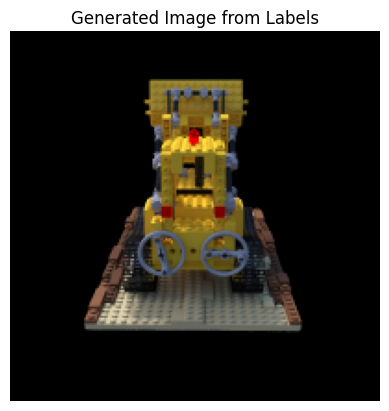

In [7]:
our_image = dataset.rays_single_image(0)[2].numpy().reshape(200, 200, 3)

print(our_image.shape)

plt.imshow(our_image)
plt.title('Generated Image from Labels')
plt.axis('off')
plt.show()

In [8]:
# Sampling along rays
def sample_along_rays(ray_o, ray_d, perturb=True):
    # we can set it to 64 later for better results
    t = torch.linspace(2., 6., 64).to(device)
    ray_o = ray_o.to(device)
    ray_d = ray_d.to(device)
    ray_d = ray_d.unsqueeze(-1)
    ray_o = ray_o.unsqueeze(-1)
    if perturb:
        t = t + (torch.rand(t.shape, device=device) * 0.02)
    t = t.view(1, 1, -1)
    x = ray_o + ray_d * t
    # Nochmal damit das so ist wie im anderen
    x = x.permute(0, 2, 1).permute(1, 0, 2)
    return x

our_image = dataset.rays_single_image(2)

ray_o, ray_d, label = our_image
print(sample_along_rays(ray_o, ray_d, perturb=True).shape)

print(f"ray_o shape: {ray_o.shape}")
print(f"ray_d shape: {ray_d.shape}")
print(f"label shape: {label.shape}")


torch.Size([64, 40000, 3])
ray_o shape: torch.Size([40000, 3])
ray_d shape: torch.Size([40000, 3])
label shape: torch.Size([40000, 3])


In [ ]:
import viser, time  # pip install viser
import numpy as np

# --- You Need to Implement These ------

# Uncoment this to display random rays from the first image
# pixeldataset = create_dataset(no_cameras=1)

# Uncomment this to select only the top left corner of the first image
# pixeldataset = create_dataset(custom_height=100, custom_width=100, no_cameras=1)

dataset = RaysData(images_train, K, c2ws_train)

# dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

# rays_o = None
# rays_d = None
# label = None

rays_o, rays_d, label = dataset.sample_rays(100)

# # Iterate through the dataset
# for ray_o_i, ray_d_i, label_i in dataloader:
#     rays_o = ray_o_i
#     rays_d = ray_d_i
#     label = label_i
#     break

# rays_o, rays_d, label = dataset.rays_single_image(81)
# rays_o = rays_o[-100:]
# rays_d = rays_d[-100:]
# label = label[-100:]

points = sample_along_rays(rays_o, rays_d, perturb=True)
rays_o = rays_o.detach().cpu().numpy()

rays_d = rays_d.detach().cpu().numpy()


print(rays_o.shape)
print(rays_d.shape)
print(points.shape)

points = points.detach().cpu().numpy()

# dataset = RaysData(images_train, K, c2ws_train)
# rays_o, rays_d, pixels = dataset.sample_rays(100) # Should expect (B, 3)
# points = sample_along_rays(rays_o, rays_d, perturb=True)
H, W = images_train.shape[1:3]
# ---------------------------------------

server = viser.ViserServer(share=True)
for i, (image, c2w) in enumerate(zip(images_train, c2ws_train)):
# for i, (image, c2w) in enumerate(zip(images_train, c2ws_train)):
    server.add_camera_frustum(
        f"/cameras/{i}",
        fov=2 * np.arctan2(H / 2, K[0, 0].detach().cpu().numpy()),
        aspect=W / H,
        scale=0.15,
        wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
        position=c2w[:3, 3],
        image=image
    )
for i, (o, d) in enumerate(zip(rays_o, rays_d)):
    server.add_spline_catmull_rom(
        f"/rays/{i}", positions=np.stack((o, o + d * 6.0)),
    )
server.add_point_cloud(
    f"/samples",
    colors=np.zeros_like(points).reshape(-1, 3),
    points=points.reshape(-1, 3),
    point_size=0.02,
)
time.sleep(1000)

(100, 3)
(100, 3)
torch.Size([64, 100, 3])


╭──────────────── viser ────────────────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 32 clients): https://sample-safe.share.viser.studio

/var/folders/m1/63ns6dts5dlf4t76wyvsczgm0000gn/T/ipykernel_57002/1185675226.py:55: DeprecationWarning: ViserServer.add_camera_frustum has been deprecated, use ViserServer.scene.add_camera_frustum instead. Alternatively, pin to `viser<0.2.0`.
  server.add_camera_frustum(
/var/folders/m1/63ns6dts5dlf4t76wyvsczgm0000gn/T/ipykernel_57002/1185675226.py:65: DeprecationWarning: ViserServer.add_spline_catmull_rom has been deprecated, use ViserServer.scene.add_spline_catmull_rom instead. Alternatively, pin to `viser<0.2.0`.
  server.add_spline_catmull_rom(
/var/folders/m1/63ns6dts5dlf4t76wyvsczgm0000gn/T/ipykernel_57002/1185675226.py:68: DeprecationWarning: ViserServer.add_point_cloud has been deprecated, use ViserServer.scene.add_point_cloud instead. Alternatively, pin to `viser<0.2.0`.
  server.add_point_cloud(


(viser) Connection closed (0, 0 total)

(viser) Connection opened (0, 1 total), 608 persistent messages

KeyboardInterrupt: 

(viser) Connection closed (0, 0 total)

In [49]:
# Create our mlp
# We input a 2d point and get the color for it, meaning 3d output rgb

# Positional encoding
# Here we just concat x with the sin and cos of L*2 amount of frequencies
class PE(nn.Module):
    def __init__(self, L=4):
        super(PE, self).__init__()
        self.L = L

    def forward(self, x):
        out = x
        for i in range(self.L):
            out = torch.cat([out, torch.sin(torch.pi * x * 2**i), torch.cos(torch.pi * x * 2**i)], dim=-1)
        return out

class MLP(torch.nn.Module):
    def __init__(self, input_size, hidden_size=256, L=4):
        super(MLP, self).__init__()
        self.pe_x = PE(L=10)
        self.pe_rd = PE(L=4)
        self.p1 = torch.nn.Sequential(
            nn.Linear((10*2+1)*input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
        )

        self.p2 = torch.nn.Sequential(
            nn.Linear(hidden_size + (10*2+1)*input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
        )
        self.density = torch.nn.Sequential(
            nn.Linear(hidden_size, 1),
            nn.ReLU(),
        )

        self.linear256 = nn.Linear(hidden_size, hidden_size)

        self.rgb = torch.nn.Sequential(
            nn.Linear(hidden_size + (4*2+1)*input_size, hidden_size//2),
            nn.ReLU(),
            nn.Linear(hidden_size//2, 3),
            nn.Sigmoid(),
        )

    def forward(self, x, rd):
        pe = self.pe_x(x)
        p1 = self.p1(pe)
        catp1 = torch.cat([pe, p1], dim=-1)

        p2 = self.p2(catp1)
        density = self.density(p2)

        lin256 = self.linear256(p2)
        rdpe = self.pe_rd(rd)
        catp2 = torch.cat([rdpe, lin256], dim=-1)
        rgb = self.rgb(catp2)
        return density, rgb

In [50]:
# Volume rendering
def volrend(sigmas, rgbs):
    step_size=(6.0 - 2.0) / 64
    sigmas = sigmas.to(device)
    rgbs = rgbs.to(device)
    batches = sigmas.shape[0]
    alpha = 1 - torch.exp(-step_size * sigmas)
    Ti = torch.cat([torch.ones((batches, 1, 1), device=device), torch.exp(torch.cumsum(sigmas, dim=1)[:, :-1] * -step_size)], dim=1)
    Ti = Ti.to(device)
    weights = alpha * Ti
    finalcolor = torch.sum(weights * rgbs, dim=1)
    return finalcolor


In [51]:
# # Testing the volume rendering
# import torch
# torch.manual_seed(42)
# sigmas = torch.rand((10, 64, 1))
# rgbs = torch.rand((10, 64, 3))
# step_size = (6.0 - 2.0) / 64
# rendered_colors = volrend(sigmas, rgbs, step_size)

# correct = torch.tensor([
#     [0.5006, 0.3728, 0.4728],
#     [0.4322, 0.3559, 0.4134],
#     [0.4027, 0.4394, 0.4610],
#     [0.4514, 0.3829, 0.4196],
#     [0.4002, 0.4599, 0.4103],
#     [0.4471, 0.4044, 0.4069],
#     [0.4285, 0.4072, 0.3777],
#     [0.4152, 0.4190, 0.4361],
#     [0.4051, 0.3651, 0.3969],
#     [0.3253, 0.3587, 0.4215]
#   ])
# assert torch.allclose(rendered_colors.cpu(), correct, rtol=1e-4, atol=1e-4)
# # print(rendered_colors.shape)

In [52]:
# a, b, c = dataset.rays_single_image(80)
# pixeldataset = TensorDataset(a, b, c)
# train_loader = DataLoader(pixeldataset, batch_size=10000, shuffle=True)

# sample_rays
# train_loader = DataLoader(dataset, batch_size=10000, shuffle=True)

def compute_psnr(mse):
    return 10 * np.log10(1. / mse)

# Training loop
def train(dataset, val_loader, hidden_dim=256, lr=1e-3, num_iterations=1100):
    # Initialize components
    model = MLP(input_size=3, hidden_size=hidden_dim).to(device)
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []
    steps = []
    # Training loop
    for iteration in range(num_iterations):
        # rays_o, rays_d, pixels = next(iter(train_loader))
        rays_o, rays_d, pixels = dataset.sample_rays(10000)
        rays_o = rays_o.to(device)
        rays_d = rays_d.to(device)
        pixels = pixels.to(device)
        points = sample_along_rays(rays_o, rays_d, perturb=True)
        points = points.permute(1, 0, 2)
        rays_d = rays_d.unsqueeze(1).repeat(1, points.shape[1], 1)

        sigmas, rgb = model(points, rays_d)
        comp_rgb = volrend(sigmas, rgb)

        loss = criterion(comp_rgb, pixels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Iteration {iteration}, PSNR: {compute_psnr(loss.item())}")
        # mse = np.mean((image1 - image2) ** 2)
        losses.append(compute_psnr(loss.item()))
        steps.append(iteration + 1)
        if (iteration + 1) % 100 == 0:
            result = None

            model.eval()
            with torch.no_grad():
                for rays_o, rays_d, pixels in val_loader:
                    rays_o = rays_o.to(device)
                    rays_d = rays_d.to(device)
                    pixels = pixels.to(device)
                    points = sample_along_rays(rays_o, rays_d, perturb=True)
                    points = points.permute(1, 0, 2)
                    rays_d = rays_d.unsqueeze(1).repeat(1, points.shape[1], 1)

                    sigmas, rgb = model(points, rays_d)
                    comp_rgb = volrend(sigmas, rgb)
                    if result is None:
                        result = comp_rgb
                    else:
                        result = torch.cat([result, comp_rgb], dim=0)
                print(result.shape)
                image = result.reshape(200, 200, 3).cpu().numpy()
                plt.imsave(f"output/nerf2/{iteration+1}render.jpg", image)
            model.train()

    plt.figure(figsize=(10, 6))
    plt.plot(steps, losses, label='Loss')

    plt.title('Validation PSNR')
    plt.xlabel('Iteration')
    plt.ylabel('PSNR')
    # plt.yscale('log')
    plt.grid(True)
    plt.legend()

    plt.show()
    return model

dataset = RaysData(images_train, K, c2ws_train)
dataset_val = RaysData(images_val[:1], K, c2ws_val[:1])
val_loader = DataLoader(dataset_val, batch_size=1000, shuffle=False)

model = train(dataset, val_loader)

Iteration 0, PSNR: 10.86057869074774
Iteration 1, PSNR: 11.74971398393997
Iteration 2, PSNR: 11.482050627137427
Iteration 3, PSNR: 11.576549012305797
Iteration 4, PSNR: 11.705070438691356
Iteration 5, PSNR: 11.72992747912372
Iteration 6, PSNR: 11.839410359626392
Iteration 7, PSNR: 11.866437373425313
Iteration 8, PSNR: 11.881394522583209
Iteration 9, PSNR: 11.914789445107864
Iteration 10, PSNR: 11.77144437228353
Iteration 11, PSNR: 11.9760819580654
Iteration 12, PSNR: 11.887836096019154
Iteration 13, PSNR: 11.875683555718883
Iteration 14, PSNR: 11.948594677500669
Iteration 15, PSNR: 11.945496720036955
Iteration 16, PSNR: 11.94446422089319
Iteration 17, PSNR: 11.966460996571646
Iteration 18, PSNR: 11.895011520306847
Iteration 19, PSNR: 11.987714124955362
Iteration 20, PSNR: 12.023439587661269
Iteration 21, PSNR: 12.108075430968977
Iteration 22, PSNR: 12.063612162628647
Iteration 23, PSNR: 12.047348211276468
Iteration 24, PSNR: 12.120550792463868
Iteration 25, PSNR: 12.166715913962225
Ite

KeyboardInterrupt: 

In [56]:
print(c2ws_test.shape)

(60, 4, 4)


In [57]:
# model = MLP(3).to(device)
# model.load_state_dict(torch.load("model.pth", map_location=torch.device(device)))
# model.eval()
dataset = RaysData(images_train[:60], K, c2ws_test)
# render images for gif
for i in range(60):
  a, b, c = dataset.rays_single_image(i)
  pixeldataset = TensorDataset(a, b, c)
  val_loader = DataLoader(pixeldataset, batch_size=1000, shuffle=False)
  iterloader = iter(val_loader)
  result = None

  model.eval()
  with torch.no_grad():
    for rays_o, rays_d, pixels in val_loader:
      rays_o = rays_o.to(device)
      rays_d = rays_d.to(device)
      pixels = pixels.to(device)
      points = sample_along_rays(rays_o, rays_d, perturb=True)
      points = points.permute(1, 0, 2)
      rays_d = rays_d.unsqueeze(1).repeat(1, points.shape[1], 1)

      sigmas, rgb = model(points, rays_d)
      comp_rgb = volrend(sigmas, rgb)
      if result is None:
        result = comp_rgb
      else:
        result = torch.cat([result, comp_rgb], dim=0)
  image = result.reshape(200, 200, 3).cpu().numpy()
  plt.imsave(f"final_render/{i}render.jpg", image)
# c = c.reshape(200, 200, 3).cpu().numpy()
# plt.imsave(f"final_render/render_truth.jpg", c)


torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size(

In [23]:
# torch.save(model.state_dict(), "model2.pth")
# # Load
# # model = YourModelClass()  # Replace with your model class
# # model.load_state_dict(torch.load("model.pth"))
# # model.eval()

# torch.save(model, "entire_model2.pth")
# # Load
# # model = torch.load("entire_model.pth")
# # model.eval()

In [54]:
def render_depth(sigmas):
    alpha = 1 - torch.exp(-sigmas * ((6.0 - 2.0) / 64))
    depths = torch.linspace(2.0, 6.0, sigmas.shape[1], device=device)
    Ti_temp = torch.exp(-torch.cumsum(sigmas, dim=1) * ((6.0 - 2.0) / 64))
    Ti = torch.cat([torch.ones((sigmas.shape[0], 1, 1), device=device), Ti_temp[:, :-1]], dim=1)
    weights = Ti * alpha
    ourdepth = torch.sum(weights * depths.unsqueeze(0).unsqueeze(-1), dim=1)
    return ourdepth

In [ ]:
# render images for depth
for i in range(60):
  a, b, c = dataset.rays_single_image(i)
  pixeldataset = TensorDataset(a, b, c)
  val_loader = DataLoader(pixeldataset, batch_size=1000, shuffle=False)
  iterloader = iter(val_loader)
  result = None

  model.eval()
  with torch.no_grad():
    for rays_o, rays_d, pixels in val_loader:
      rays_o = rays_o.to(device)
      rays_d = rays_d.to(device)
      pixels = pixels.to(device)
      points = sample_along_rays(rays_o, rays_d, perturb=True)
      points = points.permute(1, 0, 2)
      rays_d = rays_d.unsqueeze(1).repeat(1, points.shape[1], 1)

      sigmas, rgb = model(points, rays_d)
      comp_rgb = render_depth(sigmas)
      if result is None:
        result = comp_rgb
      else:
        result = torch.cat([result, comp_rgb], dim=0)
  image = result.reshape(200, 200, 1).cpu().numpy()
  image = np.squeeze(image)
  image = (image - np.min(image)) / (np.max(image) - np.min(image))
  plt.imsave(f"final_render/depth_render{i}.jpg", image, cmap='gray')

In [39]:
# model = MLP(3).to(device)
# model.load_state_dict(torch.load("model.pth", map_location=torch.device('mps')))
# model.eval()
dataset_val = RaysData(images_val, K, c2ws_val)
a, b, c = dataset_val.rays_single_image(2)
pixeldataset = TensorDataset(a, b, c)

model.eval()
print(len(pixeldataset))

val_loader = DataLoader(pixeldataset, batch_size=1000, shuffle=False)
iterloader = iter(val_loader)
result = None

with torch.no_grad():
  for rays_o, rays_d, pixels in val_loader:
    rays_o = rays_o.to(device)
    rays_d = rays_d.to(device)
    pixels = pixels.to(device)
    points = sample_along_rays(rays_o, rays_d, perturb=True)
    points = points.permute(1, 0, 2)
    rays_d = rays_d.unsqueeze(1).repeat(1, points.shape[1], 1)

    sigmas, rgb = model(points, rays_d)
    # comp_rgb = volrend(sigmas, rgb)
    comp_rgb = render_depth(sigmas)
    if result is None:
      result = comp_rgb
    else:
      result = torch.cat([result, comp_rgb], dim=0)
print(result.shape)
image = result.reshape(200, 200, 1).cpu().numpy()
image = np.squeeze(image)
print(image.shape)
plt.imsave(f"final_render/render.jpg", image, cmap='gray')
c = c.reshape(200, 200, 3).cpu().numpy()
plt.imsave(f"final_render/render_truth.jpg", c)

40000
torch.Size([40000, 1])
(200, 200)
